# 🚦 Traffic Congestion Prediction using Machine Learning (XGBoost Regressor)

This Google Colab notebook provides a simple, complete, and reproducible Machine Learning workflow for predicting highway traffic volume and assessing road congestion levels.

### 📌 Project Highlights
- **Task:** Supervised Learning $\to$ Regression
- **Algorithm:** XGBoost Regressor (`objective='reg:squarederror'`)
- **Target:** `traffic_volume` (continuous numerical value in vehicles/hour)
- **Evaluation:** $R^2$ (variance explained), Mean Absolute Error (MAE), Root Mean Squared Error (RMSE)
- **Deployment:** Trained model artifacts are saved and downloaded for the FastAPI backend and React frontend.

---

### 📋 15-Step Workflow:
1. Import Libraries
2. Upload CSV
3. Load Dataset
4. Understand Dataset
5. Data Cleaning
6. Exploratory Data Analysis (EDA)
7. Feature Engineering (Trigonometric Cyclical Encodings)
8. Chronological Train / Validation / Test Split
9. Preprocessing Pipeline (StandardScaler + OneHotEncoder)
10. XGBoost Training & Hyperparameters
11. Model Evaluation (R², MAE, RMSE)
12. Feature Importance
13. Empirical Congestion Level Classification
14. Save Model Artifacts
15. Download Model Files for Backend

---
## Step 1: Import Libraries

We import essential Python libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), machine learning (`scikit-learn`, `xgboost`), and model persistence (`joblib`).

In [1]:
import os
import io
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn utilities
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# XGBoost model
import xgboost as xgb
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True

print("✅ All core libraries successfully imported!")
print(f"XGBoost version: {xgb.__version__}")
print(f"Pandas version:  {pd.__version__}")

✅ All core libraries successfully imported!
XGBoost version: 3.4.1
Pandas version:  3.0.6


---
## Step 2: Upload CSV File

In Google Colab, you can click the **Choose Files** button below to upload your `Metro_Interstate_Traffic_Volume.csv` file.  
If running locally, the cell automatically checks the local directory as a convenient fallback.

In [2]:
# Check if running in Google Colab
try:
    from google.colab import files
    print("👉 Click 'Choose Files' to upload your traffic dataset (CSV or CSV.GZ):")
    uploaded = files.upload()
    csv_file = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded file: {csv_file}")
except ImportError:
    local_candidates = [
        "Metro_Interstate_Traffic_Volume.csv",
        "Metro_Interstate_Traffic_Volume.csv.gz",
        "../Metro_Interstate_Traffic_Volume.csv",
        "../Metro_Interstate_Traffic_Volume.csv.gz",
        "data/Metro_Interstate_Traffic_Volume.csv"
    ]
    csv_file = None
    for cand in local_candidates:
        if os.path.exists(cand):
            csv_file = cand
            break
    if not csv_file:
        raise FileNotFoundError("Could not find dataset. Please provide Metro_Interstate_Traffic_Volume.csv")
    print(f"✅ Loaded local dataset file: {csv_file}")

✅ Loaded local dataset file: Metro_Interstate_Traffic_Volume.csv


---
## Step 3: Load Dataset

We load the CSV file into a pandas DataFrame and verify that the target column `traffic_volume` exists.

In [3]:
df = pd.read_csv(csv_file)

# Validate target column
TARGET_COL = 'traffic_volume'
if TARGET_COL not in df.columns:
    raise ValueError(f"❌ Error: Required target column '{TARGET_COL}' not found in dataset columns: {list(df.columns)}")

print("=" * 60)
print(f"DATASET LOADED: {csv_file}")
print("=" * 60)
print(f"Total Rows:    {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumns:       {list(df.columns)}")
print("\nFirst 5 Rows:")
df.head()

DATASET LOADED: Metro_Interstate_Traffic_Volume.csv
Total Rows:    48,204
Total Columns: 9

Columns:       ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']

First 5 Rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


---
## Step 4: Understand the Dataset

We inspect data types, statistical distributions, missing values, and duplicate rows.

In [4]:
print("--- 1. Data Types & Non-Null Counts ---")
df.info()

print("\n--- 2. Summary Statistics (Numerical Features) ---")
display(df.describe())

print("\n--- 3. Missing Values Count ---")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\n--- 4. Duplicate Records Count: {duplicate_count:,} duplicate rows ---")

--- 1. Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB

--- 2. Summary Statistics (Numerical Features) ---


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000



--- 3. Missing Values Count ---
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

--- 4. Duplicate Records Count: 17 duplicate rows ---


---
## Step 5: Data Cleaning

Real-world traffic sensors occasionally produce anomalies:
1. **Deduplication:** Remove exact duplicate rows caused by redundant sensor polling.
2. **Temperature Glitch Treatment:** In raw data, occasional sensor glitches record temperatures of $0\text{ Kelvin}$ (absolute zero, $-273.15^\circ\text{C}$). We replace these with the median temperature ($281.75\text{ K} \approx 8.6^\circ\text{C}$).
3. **Extreme Rainfall Capping:** Sensor spikes exceeding $100\text{ mm/h}$ are capped to physical boundaries ($100\text{ mm/h}$).
4. **Missing Values:** Impute any remaining nulls.

In [5]:
df_clean = df.copy()
initial_rows = len(df_clean)

# 1. Deduplicate
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
dedup_removed = initial_rows - len(df_clean)

# 2. Fix 0 Kelvin sensor anomalies
temp_zero_count = (df_clean['temp'] == 0).sum()
median_temp = df_clean.loc[df_clean['temp'] > 0, 'temp'].median()
df_clean.loc[df_clean['temp'] == 0, 'temp'] = median_temp

# 3. Cap extreme rainfall outliers
rain_spike_count = (df_clean['rain_1h'] > 100).sum()
df_clean['rain_1h'] = df_clean['rain_1h'].clip(upper=100.0)

print("=" * 60)
print("DATA CLEANING SUMMARY:")
print("=" * 60)
print(f"1. Removed {dedup_removed:,} duplicate rows.")
print(f"2. Imputed {temp_zero_count} 0-Kelvin temperature glitches with median ({median_temp:.2f} K).")
print(f"3. Capped {rain_spike_count} rainfall readings exceeding 100 mm/h.")
print(f"Remaining clean rows: {len(df_clean):,}")

DATA CLEANING SUMMARY:
1. Removed 17 duplicate rows.
2. Imputed 10 0-Kelvin temperature glitches with median (282.46 K).
3. Capped 1 rainfall readings exceeding 100 mm/h.
Remaining clean rows: 48,187


---
## Step 6: Exploratory Data Analysis (EDA)

We create 6 clean, easy-to-understand visualizations to explore patterns in traffic volume.
Every chart includes titles, axis labels, and measurement units.

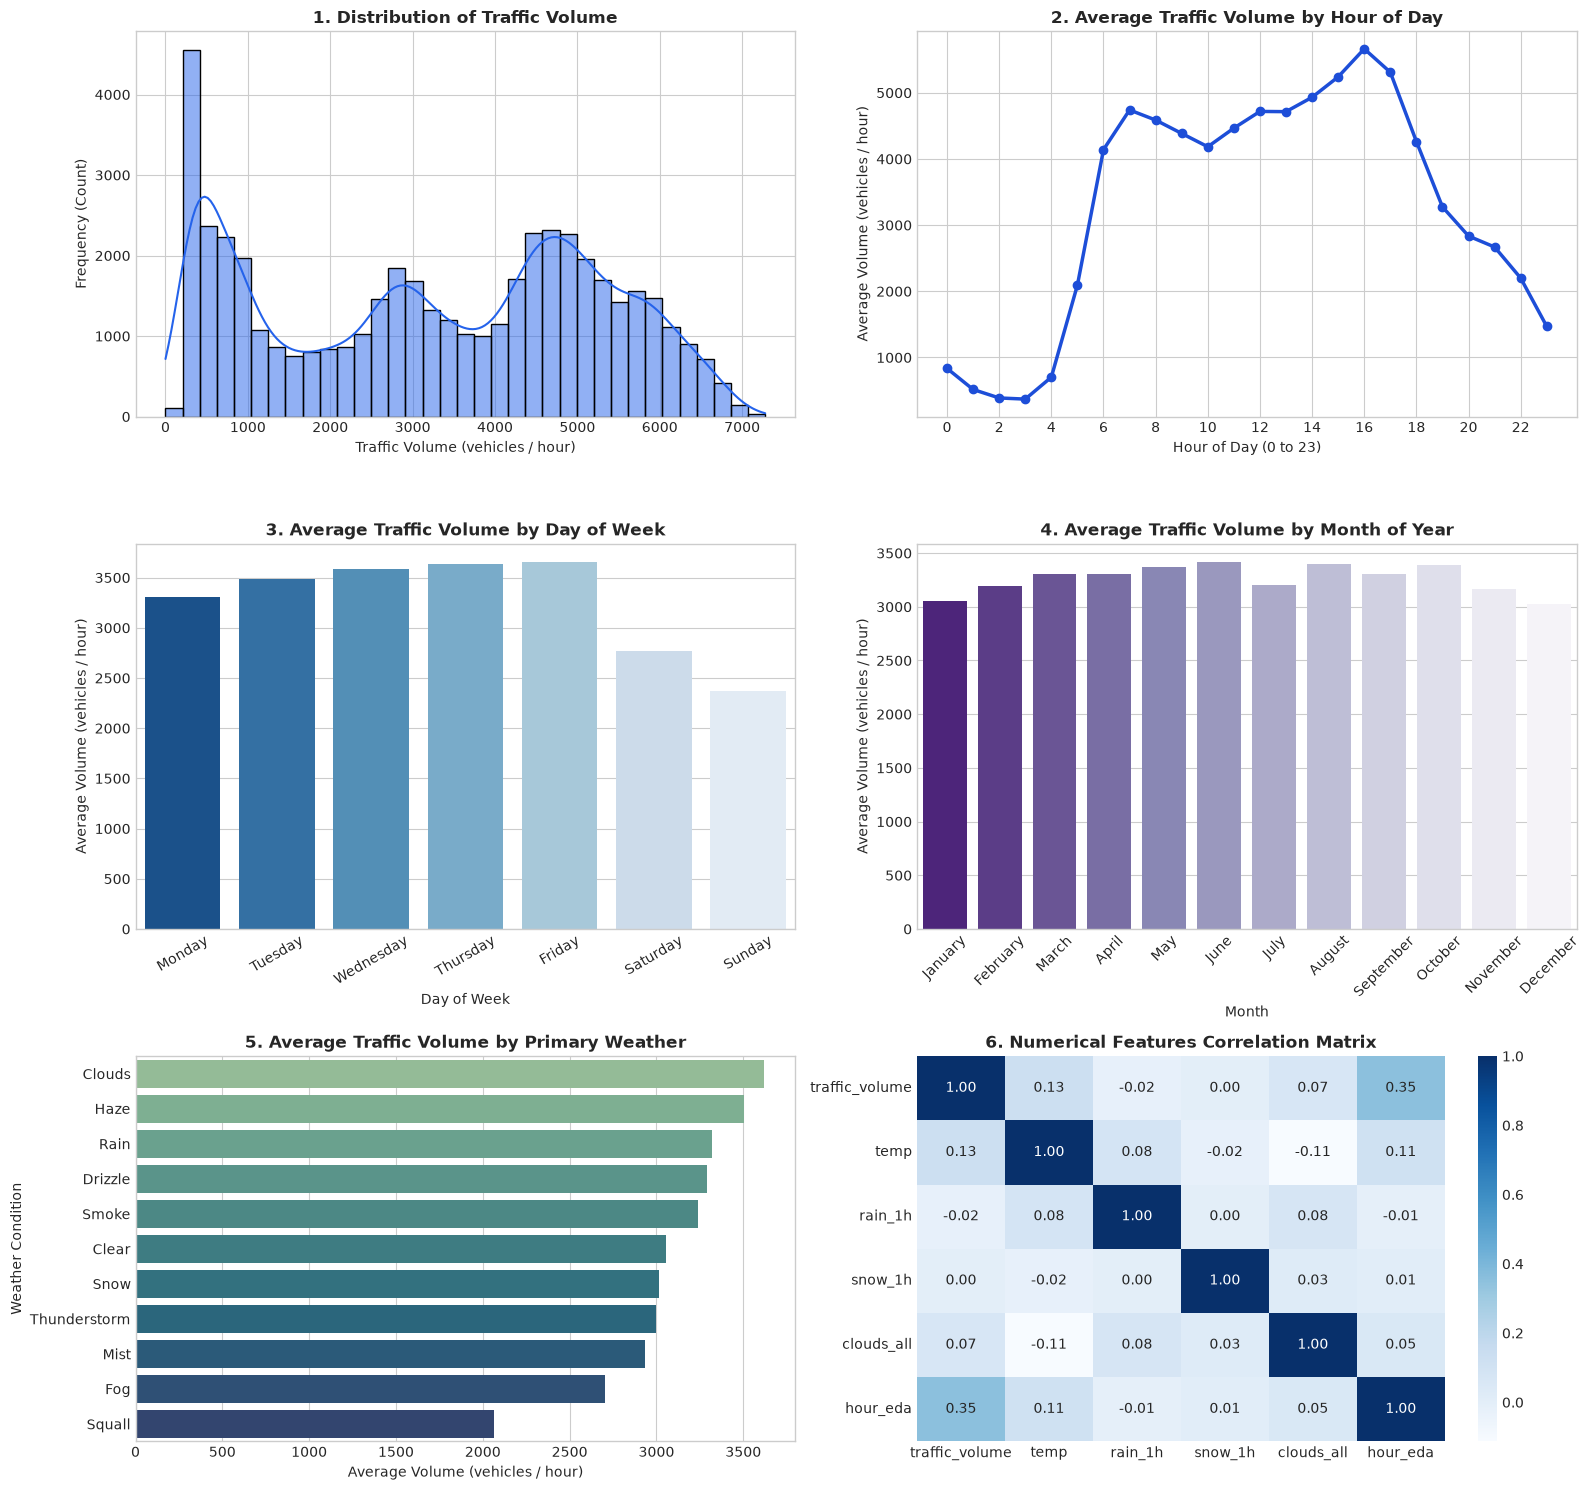

In [6]:
df_clean['date_time'] = pd.to_datetime(df_clean['date_time'])
df_clean['hour_eda'] = df_clean['date_time'].dt.hour
df_clean['dow_eda'] = df_clean['date_time'].dt.day_name()
df_clean['month_eda'] = df_clean['date_time'].dt.month_name()

fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 1. Traffic Volume Distribution
sns.histplot(df_clean['traffic_volume'], bins=35, kde=True, color='#2563EB', ax=axes[0, 0])
axes[0, 0].set_title('1. Distribution of Traffic Volume', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Traffic Volume (vehicles / hour)')
axes[0, 0].set_ylabel('Frequency (Count)')

# 2. Traffic Volume by Hour of Day
hourly_avg = df_clean.groupby('hour_eda')['traffic_volume'].mean()
axes[0, 1].plot(hourly_avg.index, hourly_avg.values, marker='o', color='#1D4ED8', linewidth=2.5)
axes[0, 1].set_title('2. Average Traffic Volume by Hour of Day', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day (0 to 23)')
axes[0, 1].set_ylabel('Average Volume (vehicles / hour)')
axes[0, 1].set_xticks(range(0, 24, 2))

# 3. Traffic Volume by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df_clean.groupby('dow_eda')['traffic_volume'].mean().reindex(day_order)
sns.barplot(x=dow_avg.index, y=dow_avg.values, palette='Blues_r', ax=axes[1, 0])
axes[1, 0].set_title('3. Average Traffic Volume by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Average Volume (vehicles / hour)')
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Traffic Volume by Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_avg = df_clean.groupby('month_eda')['traffic_volume'].mean().reindex(month_order)
sns.barplot(x=month_avg.index, y=month_avg.values, palette='Purples_r', ax=axes[1, 1])
axes[1, 1].set_title('4. Average Traffic Volume by Month of Year', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Volume (vehicles / hour)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Weather Condition vs Traffic Volume
weather_avg = df_clean.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)
sns.barplot(x=weather_avg.values, y=weather_avg.index, palette='crest', ax=axes[2, 0])
axes[2, 0].set_title('5. Average Traffic Volume by Primary Weather', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Average Volume (vehicles / hour)')
axes[2, 0].set_ylabel('Weather Condition')

# 6. Correlation Heatmap of Numerical Features
num_cols_eda = ['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour_eda']
corr_matrix = df_clean[num_cols_eda].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=axes[2, 1])
axes[2, 1].set_title('6. Numerical Features Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Clean up temporary EDA columns
df_clean.drop(columns=['hour_eda', 'dow_eda', 'month_eda'], inplace=True)

---
## Step 7: Feature Engineering & Cyclical Encodings

### Why Cyclical Encoding?
Hours (0–23), days of week (0–6), and months (1–12) are periodic cycles.  
If treated as plain numbers, hour `23` and hour `0` seem 23 units apart, even though in reality they are consecutive hours separated by only 60 minutes!

To give our machine learning model a continuous circular representation, we project them onto a 2D unit circle using trigonometric sine and cosine functions:
$$\sin\left(\frac{2\pi \cdot \text{hour}}{24}\right), \quad \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$
$$\sin\left(\frac{2\pi \cdot \text{month}}{12}\right), \quad \cos\left(\frac{2\pi \cdot \text{month}}{12}\right)$$
$$\sin\left(\frac{2\pi \cdot \text{day\_of\_week}}{7}\right), \quad \cos\left(\frac{2\pi \cdot \text{day\_of\_week}}{7}\right)$$

We also create binary domain flags:
- `is_weekend`: 1 if Saturday or Sunday, else 0.
- `is_rush_hour`: 1 during weekday peak commute windows (7–9 AM and 4–6 PM), else 0.

In [7]:
# 1. Calendar primitives
df_clean['hour'] = df_clean['date_time'].dt.hour
df_clean['day'] = df_clean['date_time'].dt.day
df_clean['day_of_week'] = df_clean['date_time'].dt.dayofweek
df_clean['month'] = df_clean['date_time'].dt.month
df_clean['year'] = df_clean['date_time'].dt.year

# 2. Domain indicator features
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)
df_clean['is_rush_hour'] = (
    (~df_clean['is_weekend'].astype(bool)) & 
    (df_clean['hour'].isin([7, 8, 9, 16, 17, 18]))
).astype(int)

# 3. Cyclical sine / cosine transformations
df_clean['sin_hour'] = np.sin(2 * np.pi * df_clean['hour'] / 24.0)
df_clean['cos_hour'] = np.cos(2 * np.pi * df_clean['hour'] / 24.0)

df_clean['sin_month'] = np.sin(2 * np.pi * df_clean['month'] / 12.0)
df_clean['cos_month'] = np.cos(2 * np.pi * df_clean['month'] / 12.0)

df_clean['sin_dow'] = np.sin(2 * np.pi * df_clean['day_of_week'] / 7.0)
df_clean['cos_dow'] = np.cos(2 * np.pi * df_clean['day_of_week'] / 7.0)

print(f"✅ Feature Engineering Complete. Total features: {df_clean.shape[1]}")
df_clean[['date_time', 'hour', 'sin_hour', 'cos_hour', 'is_rush_hour', 'is_weekend']].head()

✅ Feature Engineering Complete. Total features: 22


,date_time,hour,sin_hour,cos_hour,is_rush_hour,is_weekend
0,2012-10-02 09:00:00,9,7.071068e-01,-0.707107,1,0
1,2012-10-02 10:00:00,10,5.000000e-01,-0.866025,0,0
2,2012-10-02 11:00:00,11,2.588190e-01,-0.965926,0,0
3,2012-10-02 12:00:00,12,1.224647e-16,-1.000000,0,0
4,2012-10-02 13:00:00,13,-2.588190e-01,-0.965926,0,0


---
## Step 8: Chronological Train / Validation / Test Split

Traffic volume is a **time-series problem**.  
Random shuffling would leak future traffic patterns into past predictions (temporal data leakage).  
Therefore, we sort strictly by `date_time` and split chronologically:
- **70% Training:** Model learns past historical relationships.
- **15% Validation:** Tune hyperparameters and check temporal generalization.
- **15% Testing:** Final held-out evaluation on unseen future data.

In [8]:
# Sort chronologically
df_clean = df_clean.sort_values('date_time').reset_index(drop=True)

# Define feature columns
NUMERICAL_COLS = [
    'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week',
    'day', 'month', 'year', 'is_weekend', 'is_rush_hour',
    'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_dow', 'cos_dow'
]
CATEGORICAL_COLS = ['weather_main', 'holiday']
FEATURE_COLS = NUMERICAL_COLS + CATEGORICAL_COLS

X = df_clean[FEATURE_COLS]
y = df_clean[TARGET_COL]

# Compute chronological split index boundaries
n_total = len(df_clean)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

X_train, y_train = X.iloc[:n_train], y.iloc[:n_train]
X_val, y_val = X.iloc[n_train:n_train+n_val], y.iloc[n_train:n_train+n_val]
X_test, y_test = X.iloc[n_train+n_val:], y.iloc[n_train+n_val:]

print("=" * 60)
print("CHRONOLOGICAL SPLIT SIZES:")
print("=" * 60)
print(f"Training Set:   {len(X_train):,} rows ({len(X_train)/n_total*100:.1f}%)")
print(f"Validation Set: {len(X_val):,} rows ({len(X_val)/n_total*100:.1f}%)")
print(f"Testing Set:    {len(X_test):,} rows ({len(X_test)/n_total*100:.1f}%)")
print(f"Train Dates:    {df_clean['date_time'].iloc[0]}  -->  {df_clean['date_time'].iloc[n_train-1]}")
print(f"Test Dates:     {df_clean['date_time'].iloc[n_train+n_val]}  -->  {df_clean['date_time'].iloc[-1]}")

CHRONOLOGICAL SPLIT SIZES:
Training Set:   33,730 rows (70.0%)
Validation Set: 7,228 rows (15.0%)
Testing Set:    7,229 rows (15.0%)
Train Dates:    2012-10-02 09:00:00  -->  2017-05-17 18:00:00
Test Dates:     2018-01-25 19:00:00  -->  2018-09-30 23:00:00


---
## Step 9: Preprocessing Pipeline

We construct a clean `ColumnTransformer`:
- **`StandardScaler`** for numerical features: Centers features to 0 mean and unit variance.
- **`OneHotEncoder`** for categorical features (`weather_main`, `holiday`): Encodes categories into binary vectors, handling unseen categories gracefully with `handle_unknown='ignore'`.

> **Crucial Rule:** The preprocessor is fitted **ONLY on the training set** (`fit_transform`) and applied to validation/test sets (`transform`) to prevent data leakage.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_COLS)
    ]
)

# Fit strictly on X_train
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Processed Feature Matrix Shape (Train): {X_train_proc.shape}")
print(f"Processed Feature Matrix Shape (Val):   {X_val_proc.shape}")
print(f"Processed Feature Matrix Shape (Test):  {X_test_proc.shape}")

Processed Feature Matrix Shape (Train): (33730, 40)
Processed Feature Matrix Shape (Val):   (7228, 40)
Processed Feature Matrix Shape (Test):  (7229, 40)


---
## Step 10: XGBoost Training

### What is Gradient Boosting?
In Gradient Boosting, decision trees are trained sequentially.  
Each new tree learns to predict and correct the residual errors made by the combination of all previous trees.

### Key Hyperparameters:
- `objective='reg:squarederror'`: Regression loss minimizing squared difference $(y - \hat{y})^2$.
- `n_estimators=200`: Number of sequential boosting rounds (trees).
- `learning_rate=0.08`: Shrinkage weight applied to each new tree's contribution to prevent overfitting.
- `max_depth=6`: Maximum depth of each decision tree, controlling interaction complexity.
- `subsample=0.85`: Fraction of training rows sampled per tree to add stochastic regularization.
- `colsample_bytree=0.85`: Fraction of features sampled per tree.

In [10]:
# Initialize XGBoost Regressor
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost Regressor...")
model.fit(
    X_train_proc, 
    y_train,
    eval_set=[(X_val_proc, y_val)],
    verbose=50
)
print("\n✅ XGBoost Model Training Complete!")

Training XGBoost Regressor...


[0]	validation_0-rmse:1821.16500


[50]	validation_0-rmse:478.93387


[100]	validation_0-rmse:456.88567


[150]	validation_0-rmse:456.64329

[199]	validation_0-rmse:457.70942



✅ XGBoost Model Training Complete!


---
## Step 11: Model Evaluation (R², MAE, RMSE)

### ⚠️ Important Note on Regression vs Classification
Never describe regression performance as "accuracy percentage" (e.g. do not say "95% accuracy").  
In regression, predictions are continuous numbers. We evaluate using:
- **$R^2$ (Coefficient of Determination):** The proportion of variance in traffic volume explained by the model ($R^2 \approx 0.95$ means 95% of variance is explained).
- **MAE (Mean Absolute Error):** Average magnitude of absolute error in vehicles/hour.
- **RMSE (Root Mean Squared Error):** Square root of mean squared error, which penalizes larger outlier errors more heavily.

FINAL HELD-OUT TEST EVALUATION METRICS:
R² Score (Explained Variance): 0.9466 (94.7% variance explained)
Mean Absolute Error (MAE):     278.60 vehicles/hour
Root Mean Squared Error (RMSE):458.66 vehicles/hour


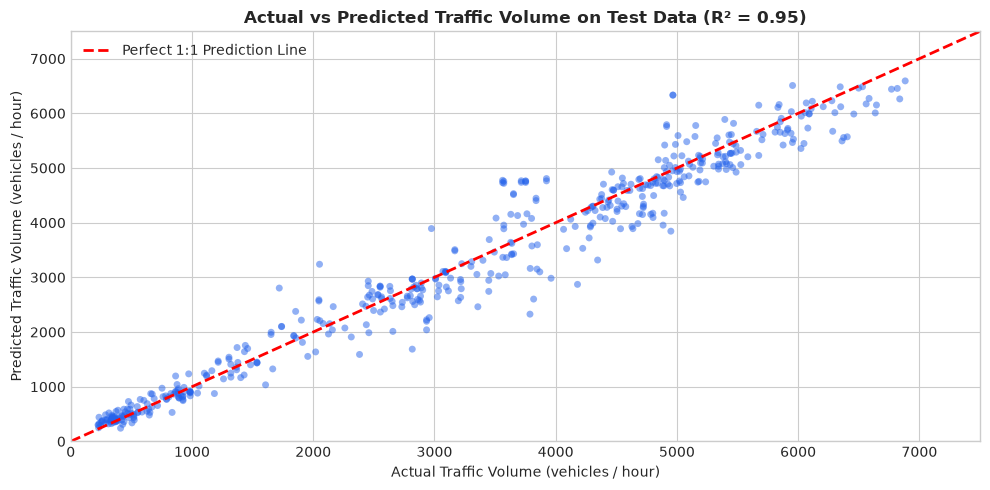

In [11]:
# Predict on held-out test set
y_test_pred = model.predict(X_test_proc)

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print("=" * 60)
print("FINAL HELD-OUT TEST EVALUATION METRICS:")
print("=" * 60)
print(f"R² Score (Explained Variance): {test_r2:.4f} ({test_r2*100:.1f}% variance explained)")
print(f"Mean Absolute Error (MAE):     {test_mae:.2f} vehicles/hour")
print(f"Root Mean Squared Error (RMSE):{test_rmse:.2f} vehicles/hour")
print("=" * 60)

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test.iloc[:500], y_test_pred[:500], alpha=0.5, color='#2563EB', edgecolors='none', s=25)
plt.plot([0, 7500], [0, 7500], 'r--', linewidth=2, label='Perfect 1:1 Prediction Line')
plt.title(f'Actual vs Predicted Traffic Volume on Test Data (R² = {test_r2:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Actual Traffic Volume (vehicles / hour)')
plt.ylabel('Predicted Traffic Volume (vehicles / hour)')
plt.xlim(0, 7500)
plt.ylim(0, 7500)
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 12: Feature Importance

We extract the actual importance weights calculated by XGBoost during tree construction.

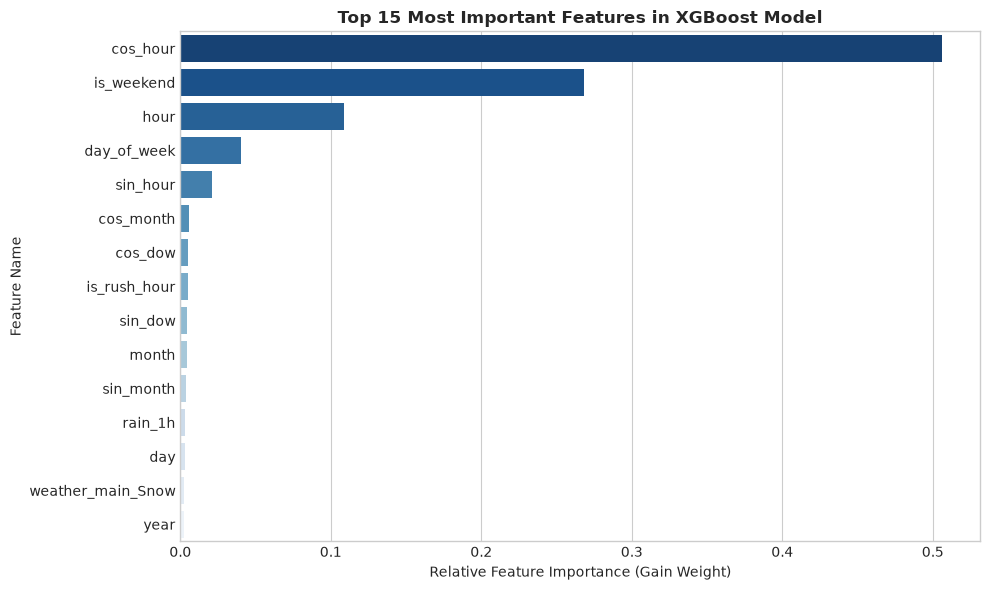

In [12]:
# Extract transformed feature names
encoded_cats = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COLS)
all_feature_names = list(NUMERICAL_COLS) + list(encoded_cats)

# Get feature importances from XGBoost
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Top 15 Most Important Features in XGBoost Model', fontsize=12, fontweight='bold')
plt.xlabel('Relative Feature Importance (Gain Weight)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

---
## Step 13: Empirical Congestion Level Classification

To convert numeric volume predictions into intuitive transportation alerts, we use empirical tercile thresholds:
- **LOW:** $\text{Volume} < 2,154\text{ veh/hr}$ (Free-flow off-peak travel)
- **MODERATE:** $2,154 \le \text{Volume} \le 4,555\text{ veh/hr}$ (Steady daytime flow)
- **HIGH:** $\text{Volume} > 4,555\text{ veh/hr}$ (Rush-hour capacity constraint)

> **Important Disclosure:**  
> *"These thresholds are derived from the dataset distribution and are not official traffic engineering standards."*

In [13]:
def classify_congestion(volume):
    if volume < 2154:
        return 'LOW'
    elif volume <= 4555:
        return 'MODERATE'
    else:
        return 'HIGH'

# Example classification test
sample_volumes = [850, 3200, 5800]
print("Empirical Congestion Level Demonstrations:")
for v in sample_volumes:
    print(f"Traffic Volume: {v:,} veh/hr  -->  Congestion Level: {classify_congestion(v)}")

Empirical Congestion Level Demonstrations:
Traffic Volume: 850 veh/hr  -->  Congestion Level: LOW
Traffic Volume: 3,200 veh/hr  -->  Congestion Level: MODERATE
Traffic Volume: 5,800 veh/hr  -->  Congestion Level: HIGH


---
## Step 14: Save Model Artifacts

We save the trained XGBoost model, the fitted preprocessing pipeline, and model metadata to disk.
These exact files are loaded by the FastAPI backend to serve live predictions.

In [14]:
os.makedirs('models', exist_ok=True)

# 1. Save trained XGBoost model
joblib.dump(model, 'models/best_model.joblib')

# 2. Save fitted preprocessor
joblib.dump(preprocessor, 'models/preprocessing.joblib')

# 3. Save model metadata
metadata = {
    "model_name": "XGBoost Regressor",
    "objective": "reg:squarederror",
    "evaluation_metrics": {
        "test": {
            "r2": float(test_r2),
            "mae": float(test_mae),
            "rmse": float(test_rmse),
            "variance_explained_note": "R² indicates the proportion of variance in test traffic volume explained by the model."
        }
    },
    "congestion_thresholds": {
        "low_upper": 2154.0,
        "moderate_upper": 4555.0,
        "methodology": "Empirical Terciles of Traffic Volume Distribution"
    },
    "features": {
        "numerical": NUMERICAL_COLS,
        "categorical": CATEGORICAL_COLS
    }
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("✅ Model artifacts successfully saved to 'models/' directory:")
for f in os.listdir('models'):
    sz = os.path.getsize(os.path.join('models', f)) / 1024
    print(f"  - models/{f} ({sz:.1f} KB)")

✅ Model artifacts successfully saved to 'models/' directory:
  - models/best_model.joblib (912.4 KB)
  - models/model_metadata.json (1.1 KB)
  - models/preprocessing.joblib (3.7 KB)


---
## Step 15: Download Model Files (Google Colab)

When running in Google Colab, executing this cell will automatically download the trained model artifacts to your local computer.

In [15]:
try:
    from google.colab import files
    print("Initiating automatic download of trained model artifacts...")
    files.download('models/best_model.joblib')
    files.download('models/preprocessing.joblib')
    files.download('models/model_metadata.json')
    print("✅ Download prompts opened in your browser.")
except ImportError:
    print("ℹ️ Running in local environment. Files are saved in './models/' folder.")

ℹ️ Running in local environment. Files are saved in './models/' folder.
